# Step 2 — Exploratory Data Analysis and Data Preparation

**Course:** 5286 Data Management and Analytics — Group A (2026S), WU Wien  
**Dataset:** Bank Marketing Dataset (Group 7 version)  
**Source:** Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306  
**Team members (Step 2, joint work):** Teammate A, Teammate B, Bengisu  
**Individual sections:** Step 3 Clustering — Teammate A · Step 4 Regression — Teammate B · Step 5 Classification — Bengisu

---

This notebook covers exploratory data analysis (EDA) and data preparation for the Bank Marketing dataset. The dataset contains information about direct marketing campaigns (phone calls) of a Portuguese banking institution. The goal of the campaigns was to sell bank term deposits.

The cleaned dataset produced in this notebook will serve as the input for Steps 3 (Clustering), 4 (Regression), and 5 (Classification).

**Note on encoding and scaling:** These transformations are marked as optional in this notebook. Since Steps 3, 4, and 5 are completed individually by different group members, each member may apply encoding and scaling methods suited to their specific model. The base cleaned dataset exported here retains original categorical columns.

---
## 1. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14

---
## 2. Load Data

In [6]:
df = pd.read_csv("bank_marketing.csv")
df.head()

,age,marital,education,housing,loan,contact,month,duration,pdays,TermDeposit
0,44,divorced,secondary,no,yes,cellular,jul,275,-1,no
1,39,married,primary,yes,no,unknown,may,35,-1,no
2,33,married,secondary,yes,yes,unknown,may,29,-1,no
3,38,married,unknown,yes,no,unknown,may,87,-1,no
4,49,married,primary,no,no,telephone,aug,214,-1,no


In [7]:
# Display shape, column names and data types
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(df.dtypes)

Rows: 11302 | Columns: 10
age             int64
marital        object
education      object
housing        object
loan           object
contact        object
month          object
duration        int64
pdays           int64
TermDeposit    object
dtype: object


In [8]:
# Display column names, non-null counts and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11302 entries, 0 to 11301
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          11302 non-null  int64 
 1   marital      11302 non-null  object
 2   education    11302 non-null  object
 3   housing      11302 non-null  object
 4   loan         11302 non-null  object
 5   contact      11302 non-null  object
 6   month        11302 non-null  object
 7   duration     11302 non-null  int64 
 8   pdays        11302 non-null  int64 
 9   TermDeposit  11302 non-null  object
dtypes: int64(3), object(7)
memory usage: 883.1+ KB


**Observation:** The dataset contains 11,302 rows and 10 columns. Seven columns are of object type (categorical) and three are numeric (`age`, `duration`, `pdays`). This matches the expected group-specific version of the UCI Bank Marketing dataset.

---
## 3. Summary Statistics

In [9]:
# Descriptive statistics for all columns
df.describe(include='all')

,age,marital,education,housing,loan,contact,month,duration,pdays,TermDeposit
count,11302.000000,11302,11302,11302,11302,11302,11302,11302.000000,11302.000000,11302
unique,NaN,3,4,2,2,3,12,NaN,NaN,2
top,NaN,married,secondary,yes,no,cellular,may,NaN,NaN,no
freq,NaN,6825,5815,6237,9462,7354,3469,NaN,NaN,9924
mean,40.944789,NaN,NaN,NaN,NaN,NaN,NaN,254.780570,40.343214,NaN
std,10.515934,NaN,NaN,NaN,NaN,NaN,NaN,249.525921,99.563271,NaN
min,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-1.000000,NaN
25%,33.000000,NaN,NaN,NaN,NaN,NaN,NaN,103.000000,-1.000000,NaN
50%,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,179.000000,-1.000000,NaN
75%,48.000000,NaN,NaN,NaN,NaN,NaN,NaN,313.000000,-1.000000,NaN


**Observations:**
- `age`: Ranges from 18 to 94. The distribution is right-skewed, with most clients between 30 and 50 years old.
- `duration`: Ranges from 0 to over 3,000 seconds. The mean is considerably higher than the median, indicating the presence of outliers (very long calls).
- `pdays`: The minimum value is -1. According to the data dictionary, -1 means the client was not previously contacted. This is a sentinel value, not a real measurement, and requires special treatment before modeling.

---
## 4. Missing Values

In [10]:
# Count null values per column
missing = df.isnull().sum()
print(missing)

age            0
marital        0
education      0
housing        0
loan           0
contact        0
month          0
duration       0
pdays          0
TermDeposit    0
dtype: int64


**Observation:** No null values are present in the dataset, which is consistent with the UCI data dictionary stating "Missing Attribute Values: None." However, the value -1 in the `pdays` column represents missing information (client not previously contacted) and will be treated accordingly in Section 10.

---
## 5. Duplicate Rows

In [11]:
# Checking and drop possible duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {df.shape[0]}")

42
Rows after removing duplicates: 11260


**Observation:** 42 duplicate rows were identified and removed. The cleaned dataset contains 11,260 rows.

---
## 6. Target Variable Distribution

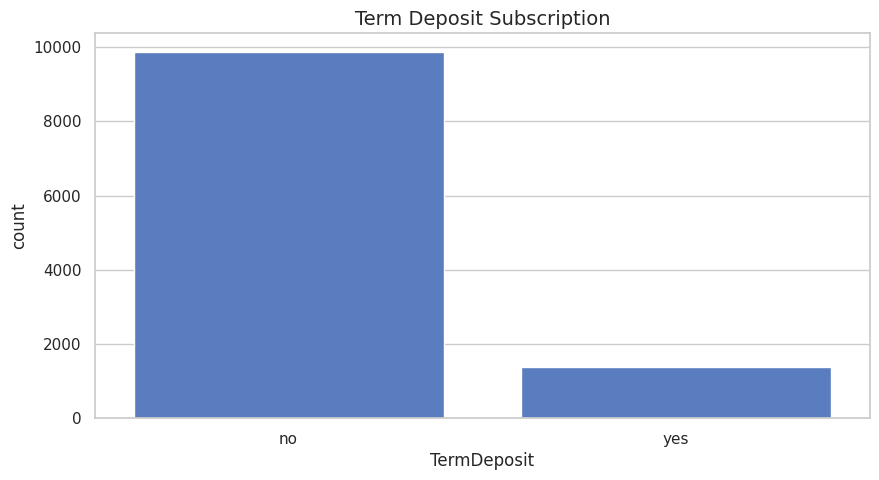

TermDeposit
no     0.87762
yes    0.12238
Name: proportion, dtype: float64


In [12]:
# Count of customers subscribing to term deposit
sns.countplot(x='TermDeposit', data=df)
plt.title("Term Deposit Subscription")
plt.show()
print(df['TermDeposit'].value_counts(normalize=True))
# Most customers didn't subscribe to term deposit

**Observation:** The target variable is imbalanced. Approximately 88% of clients did not subscribe ("no") and only 12% subscribed ("yes"). This class imbalance is important to consider when building classification models in Step 5. Techniques such as oversampling, undersampling, or using class weights may be necessary to avoid biased predictions.

---
## 7. Numerical Variable Distributions

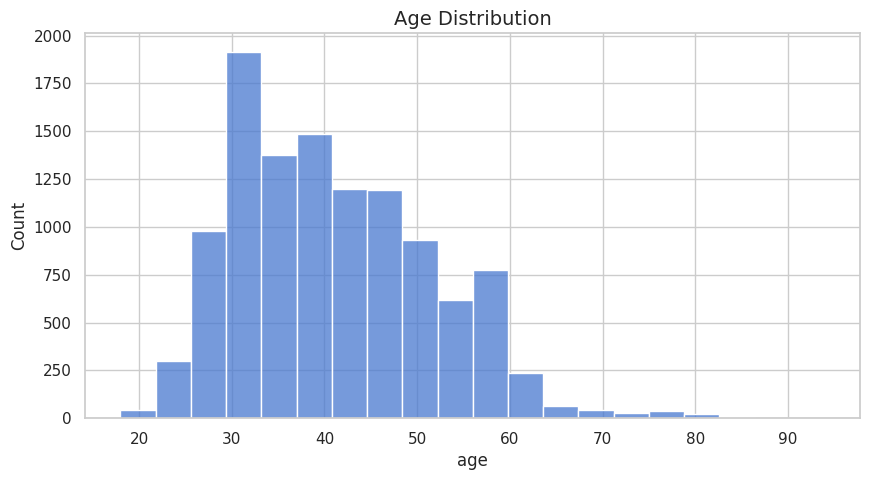

In [13]:
# Distribution of age
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()
# We can see that most customers were between ages of 30-40

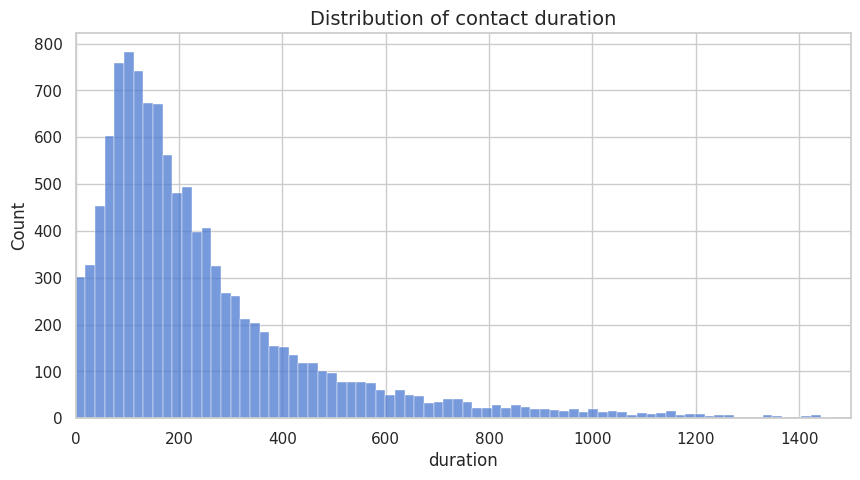

In [14]:
# Distribution of contact duration
sns.histplot(x='duration', data=df)
plt.title("Distribution of contact duration")
plt.xlim(0, 1500)
plt.show()
# The contact duration variable is right-skewed, meaning most calls are short but there are few very long calls.

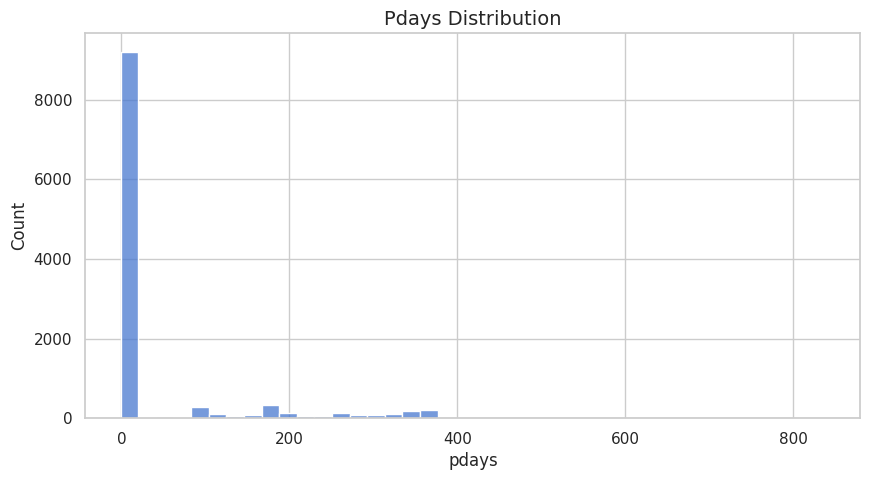

Rows with pdays = -1 (not previously contacted): 9165
Percentage: 81.4%


In [15]:
# Distribution of pdays — note the spike at -1 (client not previously contacted)
sns.histplot(data=df, x="pdays", bins=40)
plt.title("Pdays Distribution")
plt.show()

# Count of -1 values
print(f"Rows with pdays = -1 (not previously contacted): {(df['pdays'] == -1).sum()}")
print(f"Percentage: {(df['pdays'] == -1).mean() * 100:.1f}%")

**Observations:**
- `age`: The distribution is slightly right-skewed, with most clients between 30 and 40 years old.
- `duration`: Strongly right-skewed with a long tail. Most calls are short, but some last over 30 minutes. Note: call duration is only known after the call ends, so using it to predict subscription outcome introduces data leakage in a real-world scenario.
- `pdays`: Approximately 81% of values are -1, meaning the vast majority of clients were not contacted in a previous campaign. This column contains two types of information merged together: a flag (contacted or not) and a real measurement (days since contact). These will be separated in Section 10.

---
## 8. Categorical Variable Distributions

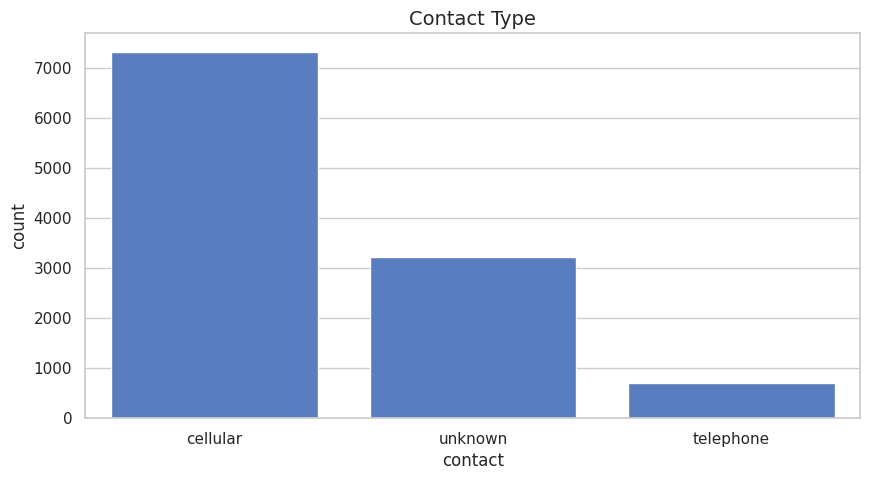

In [16]:
# Contact type
sns.countplot(x='contact', data=df)
plt.title("Contact Type")
plt.show()
# Most common contact type is cellular contact

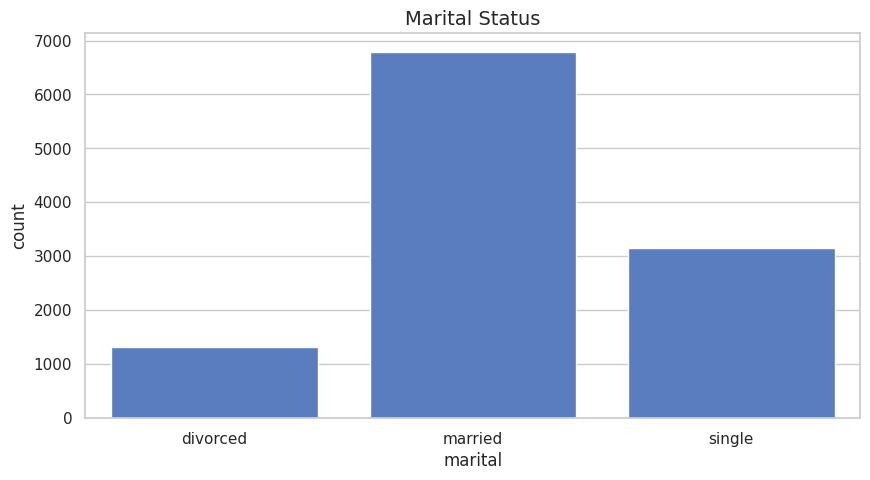

In [17]:
# Distribution of marital status
sns.countplot(data=df, x="marital")
plt.title("Marital Status")
plt.show()

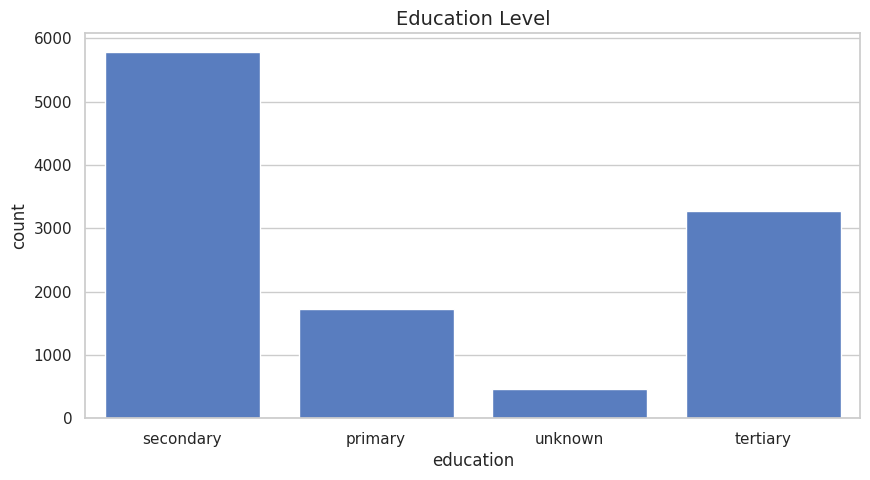

In [18]:
# Distribution of education level
sns.countplot(data=df, x="education")
plt.title("Education Level")
plt.show()

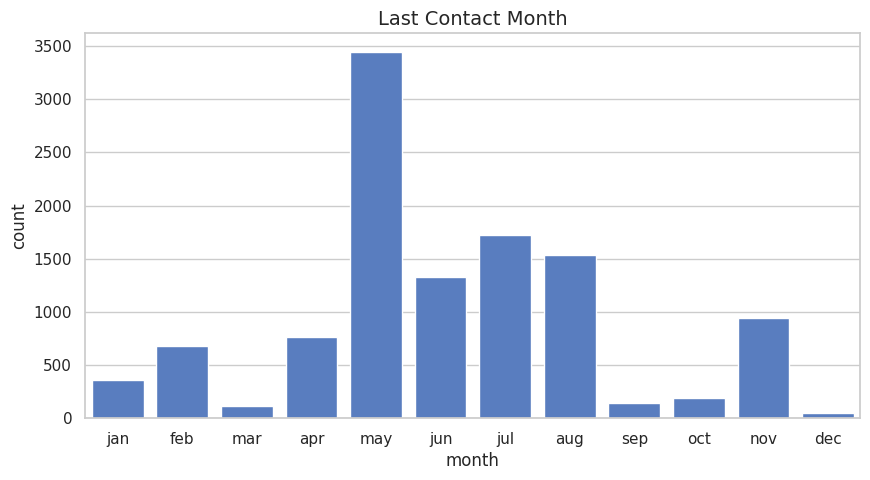

In [19]:
# Distribution of last contact month
month_order = ["jan", "feb", "mar", "apr", "may", "jun",
               "jul", "aug", "sep", "oct", "nov", "dec"]
sns.countplot(data=df, x="month", order=month_order)
plt.title("Last Contact Month")
plt.show()

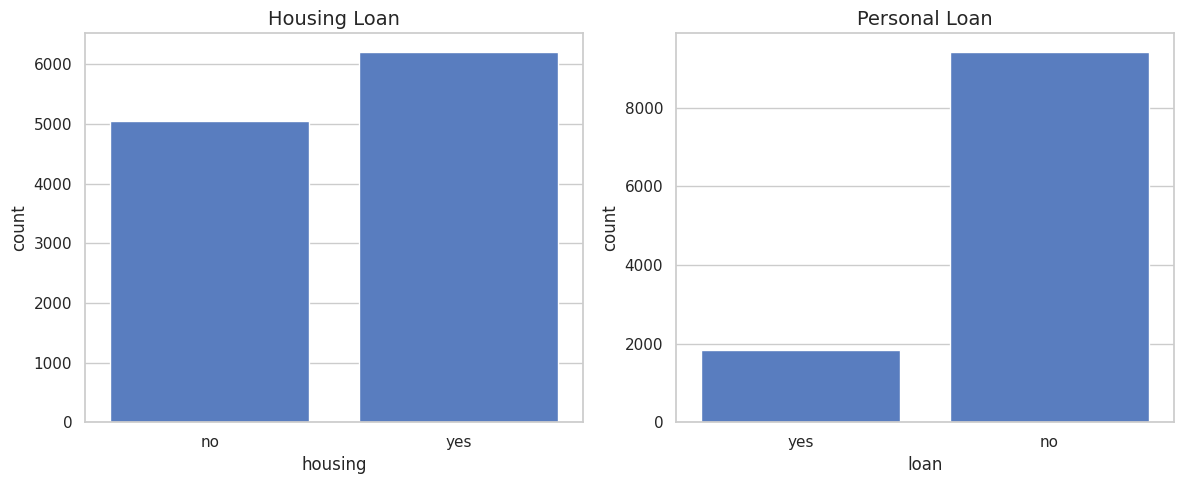

In [20]:
# Distribution of housing loan and personal loan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="housing", ax=axes[0]).set_title("Housing Loan")
sns.countplot(data=df, x="loan", ax=axes[1]).set_title("Personal Loan")
plt.tight_layout()
plt.show()

**Observations:**
- `contact`: Cellular contact is more common than telephone.
- `marital`: The majority of clients are married.
- `education`: Secondary education is the most common level. A small proportion has unknown education.
- `month`: Most contacts were made in May, followed by July and August. Contacts in March, September, October, and December are rare.
- `housing` and `loan`: More clients have a housing loan than not. Personal loans are less common.

---
## 9. Relationships with Target Variable

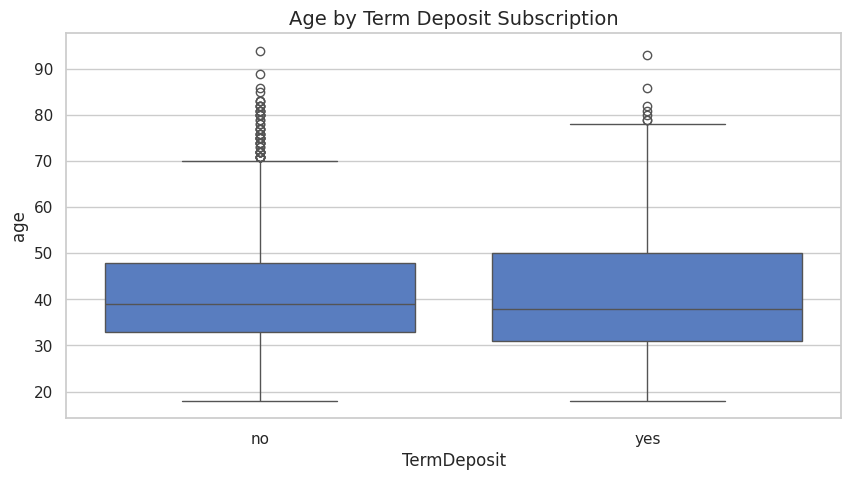

In [21]:
# Age distribution by subscription outcome
sns.boxplot(data=df, x="TermDeposit", y="age")
plt.title("Age by Term Deposit Subscription")
plt.show()

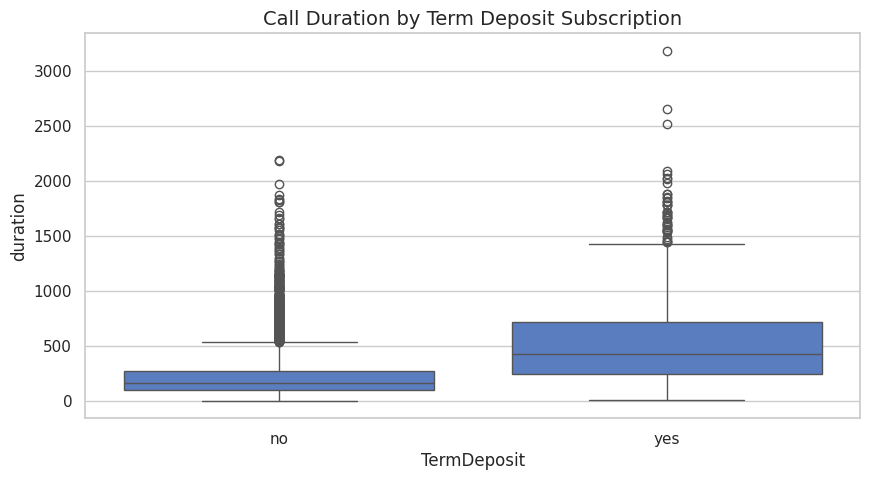

In [22]:
# Call duration distribution by subscription outcome
sns.boxplot(data=df, x="TermDeposit", y="duration")
plt.title("Call Duration by Term Deposit Subscription")
plt.show()

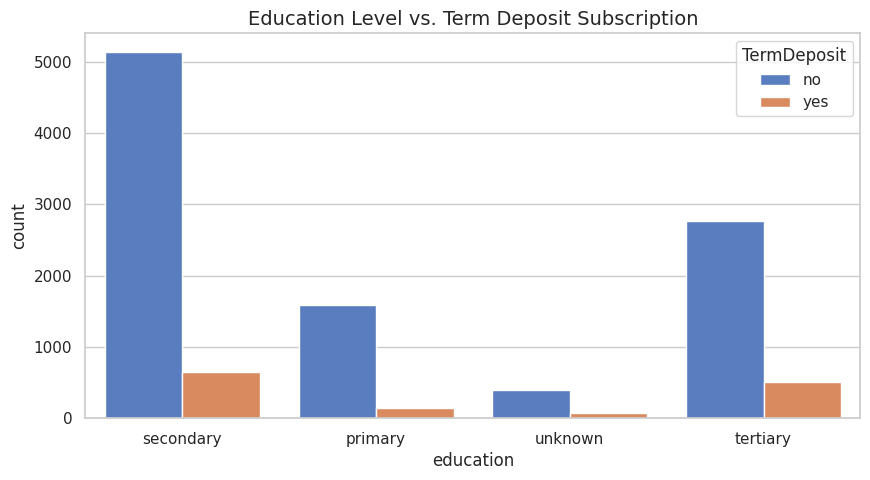

In [23]:
# Subscription rate by education level
sns.countplot(data=df, x="education", hue="TermDeposit")
plt.title("Education Level vs. Term Deposit Subscription")
plt.show()

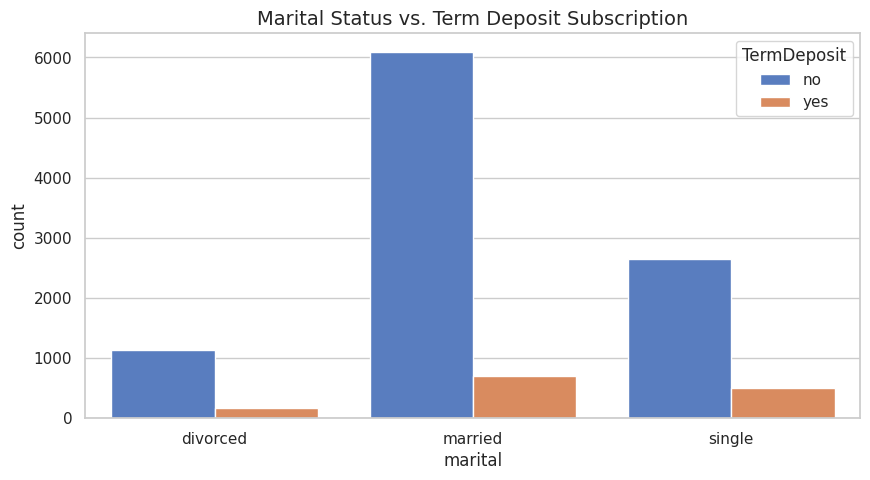

In [24]:
# Subscription rate by marital status
sns.countplot(data=df, x="marital", hue="TermDeposit")
plt.title("Marital Status vs. Term Deposit Subscription")
plt.show()

**Observations:**
- `age`: Clients who subscribed tend to be slightly older. Retired clients may show higher subscription rates.
- `duration`: Calls that ended in a subscription are noticeably longer. However, this variable should be used with caution: call duration is only known after the call ends, so using it to predict subscription outcome introduces data leakage in a real-world deployment scenario.
- `education`: Clients with tertiary education appear to have a relatively higher subscription rate.
- `marital`: Single clients show a slightly higher subscription rate compared to married or divorced clients.

---
## 10. Feature Engineering: Handling `pdays`

The `pdays` column contains two distinct pieces of information encoded in a single column:
1. Whether the client was previously contacted (-1 = no, any positive value = yes)
2. How many days ago the client was last contacted (only meaningful when not -1)

To separate these, a new binary column `contacted_before` is created. The -1 values in `pdays` are then replaced with NaN to indicate missing data, as they are not real measurements.

**Decision on `pdays`:** The column is retained after replacing -1 with NaN. Although 81% of values become NaN, the remaining 19% carry potentially useful information about clients who were previously contacted. Individual group members may choose to drop this column if their model requires complete data.

In [25]:
# Create binary column: 1 if client was previously contacted, 0 if not
df["contacted_before"] = np.where(df["pdays"] == -1, 0, 1)

# Replace -1 in pdays with NaN — it is not a real measurement
df["pdays"] = df["pdays"].replace(-1, np.nan)

# Verify distributions
print(f"contacted_before distribution:\n{df['contacted_before'].value_counts()}")

contacted_before distribution:
contacted_before
0    9165
1    2095
Name: count, dtype: int64


---
## 11. Save Cleaned Dataset

The cleaned dataset at this stage contains:
- Duplicates removed (42 rows)
- `contacted_before` column added (binary flag)
- `pdays` values of -1 replaced with NaN
- All original categorical columns retained

Encoding and scaling are left to each group member to apply within their own notebook.

In [26]:
# Save modified data to be used in next steps
df.to_csv("cleaned_bank_data.csv", index=False)
print(f"Saved: {df.shape[0]} rows, {df.shape[1]} columns")

Saved: 11260 rows, 11 columns


---
## 12. [OPTIONAL] Categorical Encoding

**Why this section is optional:**  
Encoding transforms categorical columns into numeric format required by machine learning models. However, since different modeling tasks (clustering, regression, classification) may require different encoding strategies, this step is left to each group member to apply within their own notebook.

If you choose to apply encoding here, the typical approach is:
- Binary columns (`housing`, `loan`, `TermDeposit`): map "yes" to 1 and "no" to 0
- Multi-category columns (`marital`, `education`, `contact`, `month`): use one-hot encoding (`pd.get_dummies`)

**Advantage:** Models can use all features directly.  
**Disadvantage:** One-hot encoding increases the number of columns significantly (curse of dimensionality), and the encoded dataset is less interpretable for visual analysis.

In [27]:
# OPTIONAL — run this cell only if encoding is needed for your specific task

# Binary encoding for yes/no columns
# df["housing"] = np.where(df["housing"] == "yes", 1, 0)
# df["loan"] = np.where(df["loan"] == "yes", 1, 0)
# df["TermDeposit"] = np.where(df["TermDeposit"] == "yes", 1, 0)

# One-hot encoding for multi-category columns
# df = pd.get_dummies(df, columns=["marital", "education", "contact", "month"], drop_first=True)

# print(f"Shape after encoding: {df.shape}")

---
## 13. [OPTIONAL] Scaling

**Why this section is optional:**  
Scaling normalizes numerical columns so that no single feature dominates due to its magnitude. It is required for distance-based models (K-Means clustering, KNN) and recommended for linear models. Tree-based models (Decision Trees, Random Forests) do not require scaling.

Since each group member will apply the model best suited to their task, scaling should be applied within each individual notebook.

**Note on `pdays`:** After replacing -1 with NaN, `pdays` contains 81% missing values. Applying a scaler to this column requires handling NaN values first (e.g., imputation or exclusion). Each group member should decide how to treat this column for their specific model.

In [28]:
# OPTIONAL — run this cell only if scaling is needed for your specific task
# from sklearn.preprocessing import StandardScaler

# Columns to scale (exclude binary columns and handle NaN in pdays separately)
# cols_to_scale = ["age", "duration"]

# scaler = StandardScaler()
# df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

---
## Summary

The following steps were completed in this notebook:

1. Dataset loaded: 11,302 rows, 10 columns
2. 42 duplicate rows removed — final dataset: 11,260 rows
3. No null values found
4. Target variable (`TermDeposit`) is imbalanced: approximately 88% "no", 12% "yes"
5. `duration` is right-skewed and contains outliers; it should be used with care due to data leakage risk in classification
6. `pdays` was split into `contacted_before` (binary flag) and `pdays` (NaN where previously -1)
7. Cleaned dataset saved as `cleaned_bank_data.csv` with original categorical columns retained
8. Encoding and scaling are provided as optional steps to be applied per individual task

---
## References

- Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306
- UCI Dataset page: https://archive.ics.uci.edu/dataset/222/bank+marketing